# Unsupervised floe metrics

In order to determine the quality of a segmentation result we need to know what properties a "good" result has. 
* Homogeneity across spectral bands

In [67]:
using Pkg
Pkg.activate("calval")
Pkg.update(; name="IceFloeTracker", rev="main")
using IceFloeTracker
using Images
using Random
using DataFrames
using Plots
using StatsBase

dataset = Watkins2026Dataset(ref="v0.1") # [6, 13, 61, 25, 121, 150]
case = filter(f -> f.case_number in [6, 11, 13, 63, 111, 138, 150, 166]  && f.satellite=="aqua", dataset)

  Activating project at `~/Documents/research/manuscripts/cal-val_ice_floe_tracker/calval_tgrs/notebooks/calval`
    Updating registry at `~/.julia/registries/HolyLabRegistry`
    Updating git-repo `https://github.com/HolyLab/HolyLabRegistry.git`
    Updating registry at `~/.julia/registries/General.toml`
    Updating git-repo `https://github.com/WilhelmusLab/IceFloeTracker.jl.git`
     Project No packages added to or removed from `~/Documents/research/manuscripts/cal-val_ice_floe_tracker/calval_tgrs/notebooks/calval/Project.toml`
    Manifest No packages added to or removed from `~/Documents/research/manuscripts/cal-val_ice_floe_tracker/calval_tgrs/notebooks/calval/Manifest.toml`


Dataset(GitHubLoader("https://github.com/danielmwatkins/ice-floe-validation-dataset/", "v0.1", "/tmp/Watkins2026"), 8×30 DataFrame
 Row │        case_number  region         start_date  center_lon  center_lat   ⋯
     │ Int64  Int64        String         Dates.Date  Float64     Float64      ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │    11            6  baffin_bay     2022-05-30    -73.3612     75.2608   ⋯
   2 │    20           11  baffin_bay     2011-07-02    -70.7347     72.3303
   3 │    24           13  baffin_bay     2012-05-27    -69.092      74.5432
   4 │   124           63  beaufort_sea   2007-07-11   -128.157      75.5467
   5 │   220          111  greenland_sea  2012-06-23    -14.226      78.0885   ⋯
   6 │   274          138  hudson_bay     2020-05-09    -83.9204     62.769
   7 │   298          150  laptev_sea     2008-03-30    107.716      77.711
   8 │   330          166  laptev_sea     2016-09-04    136.931      79.7507
    

In [68]:
tc_imgs = modis_truecolor.(case)
fc_imgs = modis_falsecolor.(case)
labeled_floes = validated_labeled_floes.(case)
floes = validated_binary_floes.(case);

## Measures
1. Spectral angle (pixel comparison)
$$\alpha = \cos^{-1} \left(
    \frac{\mathbf{a} \cdot \mathbf{b}}{\|a\|_2 \|b\|_2} 
     \right)
    $$ This would scale as $n^2$ for computation, since it needs to be calculated for each pair of pixels in a segment. This form is compact and nice, the same equation appears in Yang et al. 2014. We can get the segment indices easily and then apply the function to an array. This function can be used while growing a segment, since the change in spectral angle should have a maximum right as you reach an object boundary. We can use an image array, or we can merge a few bands together (e.g. using 1, 2, 3, 4, and 7).
2. Segment variance
3. Contrast along boundaries (Vcp, Vest, Zeb)
4. Texture

## Concepts
See Zhang et al. 2008, Haralick and Shapiro also. Characteristic Criteria: uniformity, homogeneiety, significant difference to nearby shapes. Semantic Criteria: based on information known about the objects under consideration, such as shape. 


In [69]:
# define segment_var

In [70]:
# img needs to be 2d
function segment_var(segments, img)
    labels = keys(segment_mean(segments))
    indices = component_indices(labels_map(segments))
    return Dict(l => var(img[indices[l]]) for l in labels)
end

segment_var (generic function with 1 method)

In [71]:
labeled_floes = SegmentedImage.(tc_imgs, [Int64.(x) for x in floes]);

In [72]:
variance_b1 = segment_var(labeled_floes[1], red.(fc_imgs[1]));
variance_b2 = segment_var(labeled_floes[1], blue.(fc_imgs[1]));

In [73]:
shuffle_idx = randperm(length(labeled_floes))

8-element Vector{Int64}:
 1
 4
 7
 2
 5
 6
 3
 8

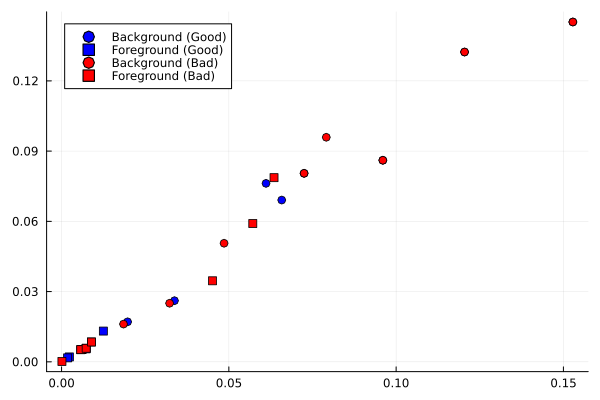

In [74]:
b1 = [green.(f) for f in fc_imgs]
b2 = [blue.(f) for f in fc_imgs]

variance_b1 = segment_var.(labeled_floes, b1);
variance_b2 = segment_var.(labeled_floes, b2);
b1_bg = variance_b1 .|> x -> x[0]
b2_bg = variance_b2 .|> x -> x[0]
b1_fg = variance_b1 .|> x -> x[1]
b2_fg = variance_b2 .|> x -> x[1]

scatter(b1_bg, b2_bg, label="Background (Good)", marker=:o, color=:blue)
scatter!(b1_fg, b2_fg, label="Foreground (Good)", marker=:r, color=:blue)

## mismatch - need to shuffle a couple times so that nothing is in the right order
variance_b1 = segment_var.(labeled_floes, b1[shuffle_idx]);
variance_b2 = segment_var.(labeled_floes, b2[shuffle_idx]);
b1_bg = variance_b1 .|> x -> x[0]
b2_bg = variance_b2 .|> x -> x[0]
b1_fg = variance_b1 .|> x -> x[1]
b2_fg = variance_b2 .|> x -> x[1]

scatter!(b1_bg, b2_bg, label="Background (Bad)", marker=:o, color=:red)
scatter!(b1_fg, b2_fg, label="Foreground (Bad)", marker=:r, color=:red)

Computing the segment variance across the binary image actually works really well for separating the good and the bad performance! Let's take a look at which images were matched:

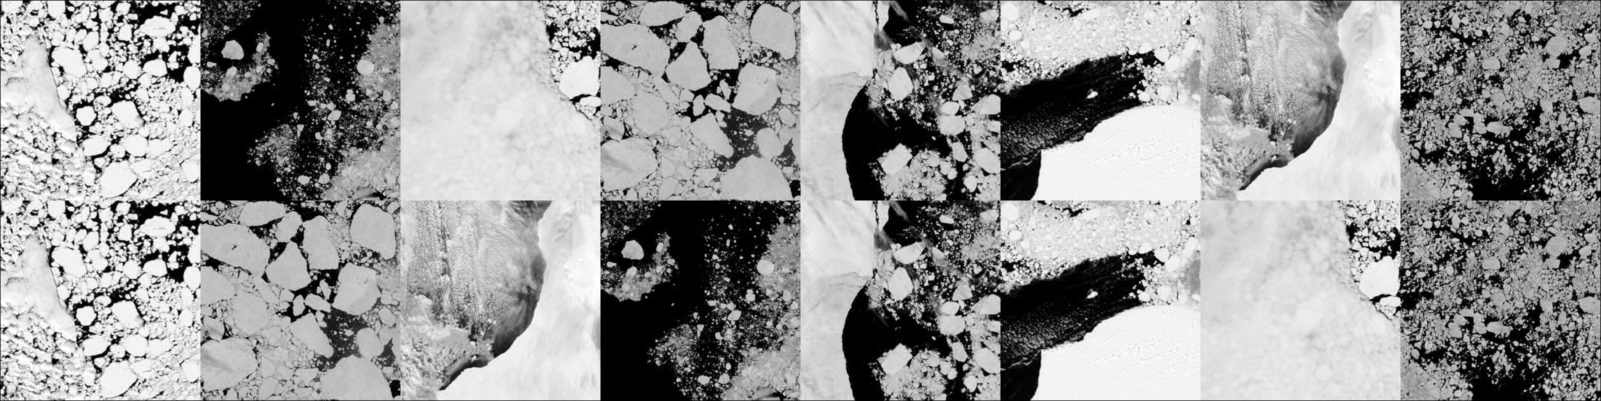

In [75]:
mosaicview(
    mosaicview([Gray.(g) for g in b1], nrow=1),
    mosaicview([Gray.(g) for g in b1[shuffle_idx]], nrow=1)
)

Now, let's look at whether we can discriminate between various choices of $k$ for the k-means step, and see how much a difference it makes to do it before or after the floe splitting step.

,,,,,,,

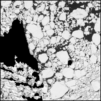
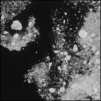
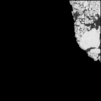
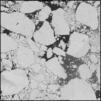
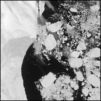
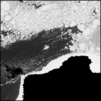
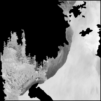
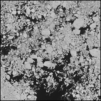

In [76]:
cloud_mask = Watkins2025CloudMask().(fc_imgs)
land_mask = modis_landmask.(case) .|> x -> x .> 0
fc_masked = apply_landmask.(fc_imgs, land_mask)
fc_masked .= apply_landmask.(fc_masked, cloud_mask)
proc_gray_masked = [Gray.(g) for g in apply_landmask.(tc_imgs, land_mask)]
proc_gray_masked .= apply_landmask.(proc_gray_masked, cloud_mask)

In [77]:
algo = IceDetectionBrightnessPeaksMODIS721(band_7_max=0.1, possible_ice_threshold=0.3; join_method="union")
bright_floes = algo.(fc_masked);
k = 3
kmeans_result_3 = kmeans_binarization.(
        proc_gray_masked,
        fc_masked;
        k=3,
        maxiter=50,
        random_seed=45,
        cluster_selection_algorithm=algo
        )
kmeans_result_4 = kmeans_binarization.(
        proc_gray_masked,
        fc_masked;
        k=4,
        maxiter=50,
        random_seed=45,
        cluster_selection_algorithm=algo
        );
kmeans_result_5 = kmeans_binarization.(
        proc_gray_masked,
        fc_masked;
        k=5,
        maxiter=50,
        random_seed=45,
        cluster_selection_algorithm=algo
        );

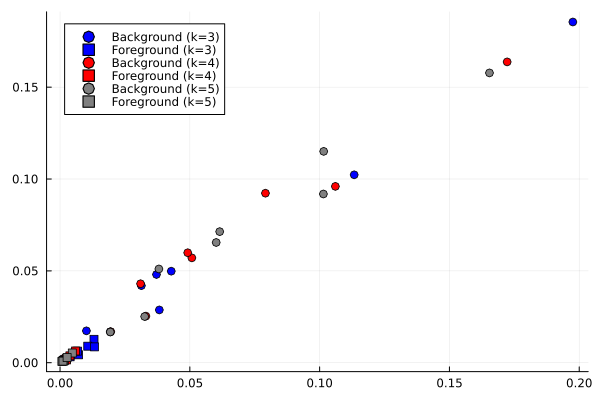

In [78]:
kmeans_segments = SegmentedImage.(tc_imgs, kmeans_result_3 .|> x -> Int64.(x));

variance_b1 = segment_var.(kmeans_segments, b1);
variance_b2 = segment_var.(kmeans_segments, b2);
b1_bg = variance_b1 .|> x -> x[0]
b2_bg = variance_b2 .|> x -> x[0]
b1_fg = variance_b1 .|> x -> x[1]
b2_fg = variance_b2 .|> x -> x[1]

scatter(b1_bg, b2_bg, label="Background (k=3)", marker=:o, color=:blue)
scatter!(b1_fg, b2_fg, label="Foreground (k=3)", marker=:r, color=:blue)

kmeans_segments = SegmentedImage.(tc_imgs, kmeans_result_4 .|> x -> Int64.(x));

variance_b1 = segment_var.(kmeans_segments, b1);
variance_b2 = segment_var.(kmeans_segments, b2);
b1_bg = variance_b1 .|> x -> x[0]
b2_bg = variance_b2 .|> x -> x[0]
b1_fg = variance_b1 .|> x -> x[1]
b2_fg = variance_b2 .|> x -> x[1]

scatter!(b1_bg, b2_bg, label="Background (k=4)", marker=:o, color=:red)
scatter!(b1_fg, b2_fg, label="Foreground (k=4)", marker=:r, color=:red)

kmeans_segments = SegmentedImage.(tc_imgs, kmeans_result_5 .|> x -> Int64.(x));

variance_b1 = segment_var.(kmeans_segments, b1);
variance_b2 = segment_var.(kmeans_segments, b2);
b1_bg = variance_b1 .|> x -> x[0]
b2_bg = variance_b2 .|> x -> x[0]
b1_fg = variance_b1 .|> x -> x[1]
b2_fg = variance_b2 .|> x -> x[1]

scatter!(b1_bg, b2_bg, label="Background (k=5)", marker=:o, color=:gray)
scatter!(b1_fg, b2_fg, label="Foreground (k=5)", marker=:r, color=:gray)

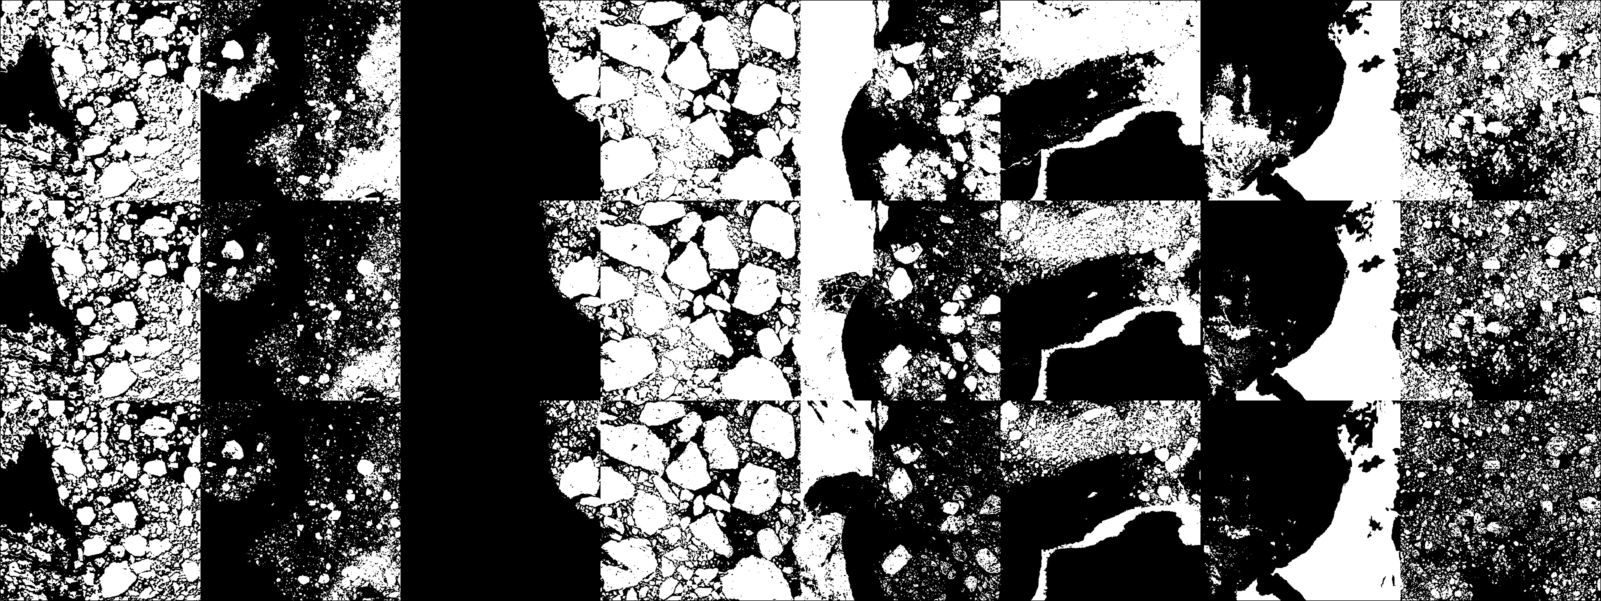

In [79]:
mosaicview(
    mosaicview(kmeans_result_3 .|> x -> Gray.(x), nrow=1),
    mosaicview(kmeans_result_4 .|> x -> Gray.(x), nrow=1),
    mosaicview(kmeans_result_5 .|> x -> Gray.(x), nrow=1)
    )

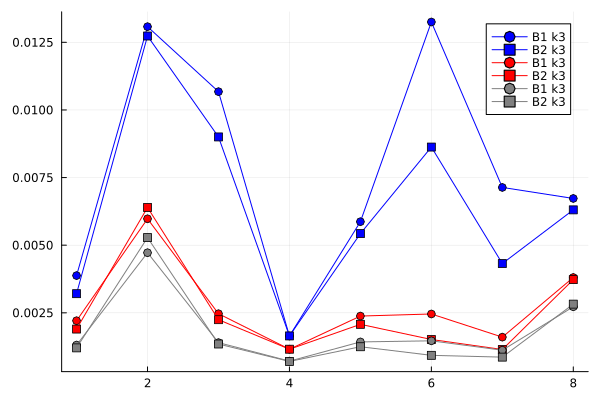

In [80]:
kmeans_segments = SegmentedImage.(tc_imgs, kmeans_result_3 .|> x -> Int64.(x));

variance_b1 = segment_var.(kmeans_segments, b1);
variance_b2 = segment_var.(kmeans_segments, b2);
b1_fg = variance_b1 .|> x -> x[1]
b2_fg = variance_b2 .|> x -> x[1]
plot(b1_fg, marker=:o, label="B1 k3", color=:blue)
plot!(b2_fg, marker=:r, label="B2 k3", color=:blue)

kmeans_segments = SegmentedImage.(tc_imgs, kmeans_result_4 .|> x -> Int64.(x));

variance_b1 = segment_var.(kmeans_segments, b1);
variance_b2 = segment_var.(kmeans_segments, b2);
b1_fg = variance_b1 .|> x -> x[1]
b2_fg = variance_b2 .|> x -> x[1]
plot!(b1_fg, marker=:o, label="B1 k3", color=:red)
plot!(b2_fg, marker=:r, label="B2 k3", color=:red)

kmeans_segments = SegmentedImage.(tc_imgs, kmeans_result_5 .|> x -> Int64.(x));

variance_b1 = segment_var.(kmeans_segments, b1);
variance_b2 = segment_var.(kmeans_segments, b2);
b1_fg = variance_b1 .|> x -> x[1]
b2_fg = variance_b2 .|> x -> x[1]
plot!(b1_fg, marker=:o, label="B1 k3", color=:gray)
plot!(b2_fg, marker=:r, label="B2 k3", color=:gray)

In all these cases we get more heterogeneity (using variance) with the lower value of $k$, which is totally expected. What's interesting is that in the clear case there's very little difference, while in the tougher case there's big gains from improving $k$. In general -- big improvements going from 3 to 4, small improvements going from 4 to 5. This is 100% expected: k-means is minimizing intra-cluster variance in the preprocessed image. 

Next, we need to see how well the segment aligns with image gradients. 
* Could get the boundary pixels and then for each boundary pixel and compute a measure there, such as the contrast across the boundary
* Zhang et al. 2008 favored the Zeb metric, which uses two computations: one on the differences between other pixels in the same region, and one along the borders of regions.

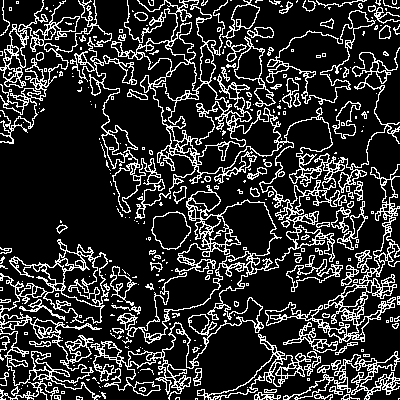

In [84]:
Gray.(isboundary(kmeans_result_3[1]))

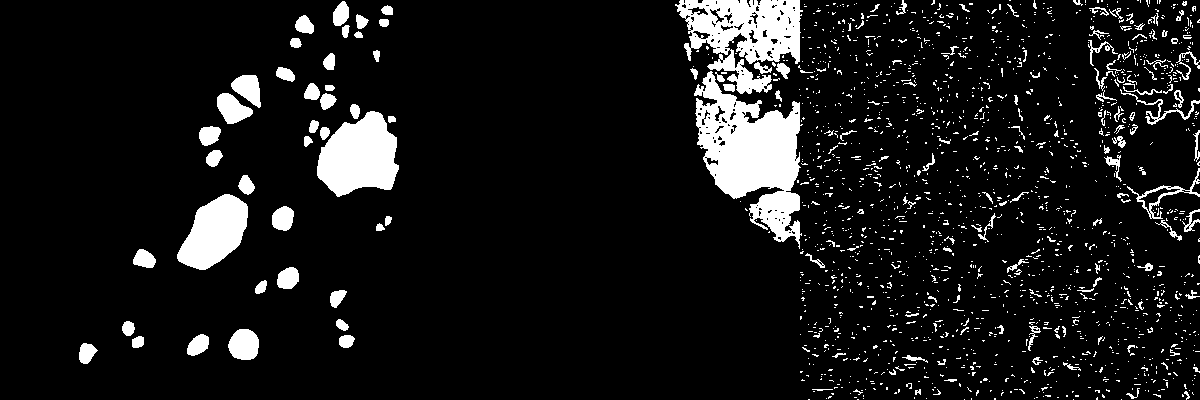

In [124]:
G = imgradientmag(Gray.(tc_imgs[3]))
mosaicview(Gray.(floes[3]), kmeans_result_3[3], Gray.(G .>  2 * imfilter(Gray.(G), Kernel.gaussian(15))), nrow=1)

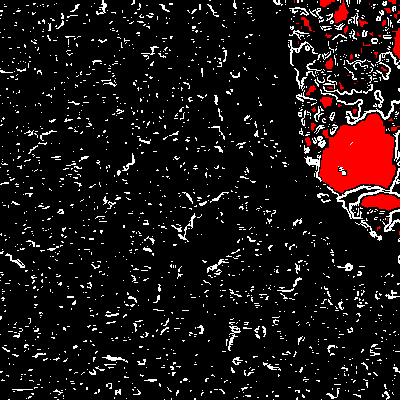

In [128]:
B = Gray.(G .>  2 * imfilter(Gray.(G), Kernel.gaussian(15)))
result = RGB.(erode(kmeans_result_4[3], strel_box((5,5))))
result[red.(result) .> 0] .= RGB(1, 0, 0)
result[B .> 0] .= RGB(1, 1, 1)
result

In [97]:
?imfilter!

search: imfilter! imfilter filter! filter imfill isfitted isfile extreme_filter!



```julia
imfilter!(imgfilt, img, kernel, [border="replicate"], [alg])
imfilter!(r, imgfilt, img, kernel, border::Pad)
imfilter!(r, imgfilt, img, kernel, border::NoPad, [inds=axes(imgfilt)])
```

Filter an array `img` with kernel `kernel` by computing their correlation, storing the result in `imgfilt`.

The indices of `imgfilt` determine the region over which the filtered image is computed–-you can use this fact to select just a specific region of interest, although be aware that the input `img` might still get padded.  Alteratively, explicitly provide the indices `inds` of `imgfilt` that you want to calculate, and use `NoPad` boundary conditions. In such cases, you are responsible for supplying appropriate padding: `img` must be indexable for all of the locations needed for calculating the output. This syntax is best-supported for FIR filtering; in particular, that that IIR filtering can lead to results that are inconsistent with respect to filtering the entire array.

See also: [`imfilter`](@ref).

---

```julia
imfilter!(::AbstractResource, imgfilt, img, kernel, NoPad(), [inds=axes(imgfilt)])
```

Filter an array `img` with kernel `kernel` by computing their correlation, storing the result in `imgfilt`, defaulting to a finite-impulse response (FIR) algorithm. Any necessary padding must have already been supplied to `img`. If you want padding applied, instead call

```julia
imfilter!([r::AbstractResource,] imgfilt, img, kernel, border)
```

with a specific `border`, or use

```julia
imfilter!(imgfilt, img, kernel, [Algorithm.FIR()])
```

for default padding.

If `inds` is supplied, only the elements of `imgfilt` with indices in the domain of `inds` will be calculated. This can be particularly useful for "cascaded FIR filters" where you pad over a larger area and then calculate the result over just the necessary/well-defined region at each successive stage.

See also: [`imfilter`](@ref).

---

```julia
imfilter!(::AbstractResource{FFT}, imgfilt, img, kernel, NoPad())
```

Filter an array `img` with kernel `kernel` by computing their correlation, storing the result in `imgfilt`, using a fast Fourier transform (FFT) algorithm. Any necessary padding must have already been applied to `img`. If you want padding applied, instead call

```julia
imfilter!(::AbstractResource{FFT}, imgfilt, img, kernel, border)
```

with a specific `border`, or use

```julia
imfilter!(imgfilt, img, kernel, Algorithm.FFT())
```

for default padding.

See also: [`imfilter`](@ref).

---

```julia
imfilter!(r::AbstractResource, imgfilt, img, kernel::Tuple{TriggsSdika...}, border)
imfilter!(r::AbstractResource, imgfilt, img, kernel::TriggsSdika, dim::Integer, border)
```

Filter an array `img` with a Triggs-Sdika infinite impulse response (IIR) `kernel`, storing the result in `imgfilt`. Unlike the `FIR` and `FFT` algorithms, this version is safe for inplace operations, i.e., `imgfilt` can be the same array as `img`.

Either specify one kernel per dimension (as a tuple), or a particular dimension `dim` along which to filter. If you exhaust `kernel`s before you run out of array dimensions, the remaining dimension(s) will not be filtered.

With Triggs-Sdika filtering, the only border options are `NA()`, `"replicate"`, or `Fill(value)`.

See also: [`imfilter`](@ref), [`KernelFactors.TriggsSdika`](@ref), [`KernelFactors.IIRGaussian`](@ref).
